In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model.parameters import *
from modules.transitory_functions import *
from scipy.optimize import approx_fprime


In [2]:
class plant:
    def __init__(self):

        self.state_name = ["C_O2_ccl", "C_v_ccl"]
        self.gradient = {}
        for name in self.state_name:
            self.gradient["d" + name + " / dt"] = 0

        # Set points
        self.P_des = 1.5e5  # Pa
        self.T_des = 333.15  # K
        self.Phi_des = 0.5 # -
        self.Sc_des = 2.5  # -
        self.i_fc = 0.5e4  # A/m2
        # Variables
        self.t = 0
        self.Tccl = 60 + 273.15  # K
        self.Pccl = 0
        self.Pcgdl = 0
        self.C_N2 = self.P_des / (R * self.T_des) - Psat(self.T_des) * 0.79  # mol/m3
        self.C_O2_cgc = 8.22  # mol/m3
        self.C_v_cgc =  self.Phi_des * Psat(self.Tccl)/(R * self.Tccl)  # mol/m3
        self.C_v_ccl = self.Sc_des*Psat(self.Tccl)
        self.lambda_ccl = 14  # -
        self.epsilon_gdl = 0.5
        self.epsilon_cl = 0.4

    def dxdt(self, t, variables):

        self.dt = t - self.t
        self.t = t
       
        sv = {}
        for i_name in range(len(self.state_name)):
            sv[self.state_name[i_name]] = variables[i_name]

        # Massflow
        
        # Immediately calculation
        Psat = 101325 * 10 ** (-2.1794 + 0.02953 * (self.Tccl - 273.15) - 9.1837e-5 * (self.Tccl - 273.15) ** 2 +1.4454e-7 * (self.Tccl - 273.15) ** 3)
        self.Pcgdl = self.P_des
        self.C_N2 = self.P_des - (sv["C_O2_ccl"] + sv["C_v_ccl"]) * (R * self.Tccl)
        self.Pccl =  (sv["C_v_ccl"] + sv["C_O2_ccl"] + self.C_N2) * R * self.Tccl
        a = self.Pccl/Psat
        self.lambda_ccl = 0.043 + 17.81*a - 39.85*a**2 + 36.0* a**3
        if self.epsilon_cl < 0.1:
            s_ccl_cgdl = 0.1
        elif self.epsilon_cl < 0.2:
            s_ccl_cgdl = 0.08
        else:
            s_ccl_cgdl = 0.02
        Pccl_cgdl = self.Pccl / 2 + self.Pcgdl / 2
        # Material properties
        epsilon_mean = self.epsilon_gdl / 2 + self.epsilon_cl / 2
        Dccl = Dc_eff(s_ccl_cgdl, epsilon_mean, Pccl_cgdl, self.Tccl, epsilon_c, self.epsilon_gdl)
        J_O2_ccl_cgdl = -  Dccl * (self.C_O2_cgc - sv["C_O2_ccl"]) / (Hgdl + Hcl)
        Jv_ccl_cgdl = -  Dccl * (self.C_v_cgc - sv['C_v_ccl']) / (Hgdl + Hcl)
        S_O2_ccl = - self.i_fc / (4 * F)
        S_sorp_ccl = gamma_sorp(sv['C_v_ccl'], s_ccl_cgdl, 14, self.Tccl, Hcl, Kshape) * rho_mem / M_eq * \
                             (lambda_eq(sv['C_v_ccl'],s_ccl_cgdl, self.Tccl, Kshape) - 14)
        Sl_ccl = Svl(s_ccl_cgdl, sv['C_v_ccl'], sv['C_v_ccl'] + sv["C_O2_ccl"] + self.C_N2, self.epsilon_cl, self.Tccl, gamma_cond, gamma_evap)
        Sv_ccl = - Sl_ccl
        
        # Mass flow of vapor at CCL

        self.gradient['dC_v_ccl / dt'] = 1 / (self.epsilon_cl * (1 - s_ccl_cgdl)) * (- Jv_ccl_cgdl / Hcl - S_sorp_ccl + Sv_ccl - S_O2_ccl*2)
        self.gradient['dC_O2_ccl / dt'] = 1 / (self.epsilon_cl * (1 - s_ccl_cgdl)) * (-J_O2_ccl_cgdl / Hcl + S_O2_ccl)

        return list(self.gradient.values())
    
    def getUcell(self, s_ccl, lambda_ccl, lambda_mem, C_O2_ccl):

        Re = 5.70e-7  # ohm.m². It is the electron conduction resistance of the circuit.
        i0_c_ref = 2.49  # A.m-2.It is the reference exchange current density at the cathode.
        kappa_c = 1.61  # It is the overpotential correction exponent.

        # The equilibrium potential
        Ueq = 1.18

        # The proton resistance
        # The proton resistance at the membrane : Rmem
        if lambda_mem >= 1:
            Rmem = Hmem / ((0.5139 * lambda_mem - 0.326) * np.exp(1268 * (1 / 303.15 - 1 / self.Tccl)))
        else:
            Rmem = Hmem / (0.1879 * np.exp(1268 * (1 / 303.15 - 1 / self.Tccl)))
        #  The proton resistance at the cathode catalyst layer : Rccl
        if lambda_ccl >= 1:
            Rccl = Hcl / ((epsilon_mc ** tau) * (0.5139 * lambda_ccl - 0.326) * np.exp(1268 * (1 / 303.15 - 1 / self.Tccl)))
        else:
            Rccl = Hcl / ((epsilon_mc ** tau) * 0.1879 * np.exp(1268 * (1 / 303.15 - 1 / self.Tccl)))

        #  The total proton resistance
        Rp = Rmem + Rccl  # its value is around [4-7]e-6 ohm.m².
        slim = a_slim * (2e5 / 1e5) + b_slim
        s_switch = a_switch * slim
        f_drop = 0.5 * (1.0 - np.tanh((4 * s_ccl - 2 * slim - 2 * s_switch) / (slim - s_switch)))
        eta_c = 1 / f_drop * R * self.Tccl / (alpha_c * F) * np.log(self.i_fc / i0_c_ref * (C_O2ref / C_O2_ccl) ** kappa_c)
        # The cell voltage
        return Ueq - self.i_fc * (Rp + Re) - eta_c

    def Y(self, x):
        C_O2_ccl = x[0]
        C_v_ccl = x[1]
        Pccl =  (C_v_ccl + C_O2_ccl + self.C_N2) * R * self.Tccl
        a = Pccl/Psat(self.Tccl)
        lambda_ccl = 0.043 + 17.81*a - 39.85*a**2 + 36.0* a**3
        self.Ucell = self.getUcell(s_ccl = 0.02, lambda_ccl = lambda_ccl, lambda_mem = lambda_ccl, C_O2_ccl = C_O2_ccl)
        return [self.Ucell]

In [3]:
class LuenbergerObserver:
    """Second-order Luenberger observer for [C_O2_ccl, C_v_ccl] state estimation"""
    
    def __init__(self, plant, L: np.ndarray, initial_state: np.ndarray):
        """
        Initialize the Luenberger observer.
        
        Args:
            plant: Reference to the plant model
            L: Observer gain matrix (2x1) - corrects both states based on output error
            initial_state: Initial state estimate [C_O2_ccl, C_v_ccl] (2x1)
        """
        self.plant = plant
        self.L = np.array(L).reshape(2, 1)  # Observer gain matrix (2x1)
        self.x_hat = np.array(initial_state).reshape(2, 1)  # Estimated state [C_O2_ccl, C_v_ccl]
        self.x_new = self.x_hat.copy()
        self.t_prev = 0
    
    def update(self, t, y_measured, u=None):
        """
        Update state estimate based on measured output and input.
        
        Args:
            t: Current time
            y_measured: Measured output (Ucell) - scalar
            u: Input (i_fc) - scalar or None (uses plant.i_fc if None)
        
        Returns:
            x_hat: Current state estimate [C_O2_ccl, C_v_ccl]
        """
        dt = t - self.t_prev
        self.t_prev = t
        
        # Set input if provided
        if u is not None:
            self.plant.i_fc = u
        
        # Get plant dynamics with estimated state
        x_hat_list = self.x_hat.flatten().tolist()
        dx_hat = np.array(self.plant.dxdt(t, x_hat_list)).reshape(2, 1)
        
        # Get predicted output from estimated state
        y_predicted = self.plant.Y(x_hat_list)[0]
        
        # Observer correction term
        innovation = y_measured - y_predicted  # Scalar
        
        # Observer dynamics: dx_hat/dt = f(x_hat, u) + L*(y_measured - y_predicted)
        # Euler integration with correction
        self.x_new = self.x_hat + dt * dx_hat
        self.x_hat = self.x_new + self.L * innovation
        
        return self.x_hat.copy()
    
    def reset(self, initial_state: np.ndarray):
        """Reset observer to initial state"""
        if initial_state is None:
            initial_state = np.array([[6.0], [2.0]])
        self.x_hat = np.array(initial_state).reshape(2, 1)
        self.x_new = self.x_hat.copy()
        self.t_prev = 0
    
    def get_estimate(self):
        """Get current state estimate"""
        return self.x_hat.copy()
    
    def set_gain(self, L: np.ndarray):
        """Update observer gain matrix"""
        self.L = np.array(L).reshape(2, 1)


In [4]:

# Function to compute observability matrix using Lie derivatives with numerical Jacobian
def compute_observability_matrix_lie(plant, x_hat, epsilon=1e-8):
    """
    Compute observability matrix O = [dh/dx; dL_f(h)/dx] using Lie derivatives
    with numerical Jacobian computation using scipy.optimize.approx_fprime
    where:
    - h(x) is the output function
    - L_f(h) is the Lie derivative of h along f (= dh/dx * f(x))
    """
    x = x_hat.flatten()
    n = len(x)

    # Define output function
    def output_func(x_vec):
        return plant.Y(x_vec.tolist())[0]

    # Compute Jacobian dh/dx using scipy's approx_fprime
    dh_dx = np.zeros((1, n))
    for i in range(n):
        epsilon_vec = np.zeros(n)
        epsilon_vec[i] = epsilon
        dh_dx[0, i] = approx_fprime(x, output_func, epsilon_vec)[i]

    # Compute f(x) - the system dynamics
    f_x = np.array(plant.dxdt(plant.t, x.tolist()))

    # Compute Lie derivative L_f(h) = dh/dx * f(x)
    L_f_h = np.dot(dh_dx, f_x)[0]

    # Define Lie derivative function
    def lie_derivative_func(x_vec):
        dh_dx_local = np.zeros(n)
        for i in range(n):
            epsilon_vec = np.zeros(n)
            epsilon_vec[i] = epsilon
            dh_dx_local[i] = approx_fprime(x_vec, output_func, epsilon_vec)[i]
        f_x_local = np.array(plant.dxdt(plant.t, x_vec.tolist()))
        return np.dot(dh_dx_local, f_x_local)

    # Compute Jacobian of Lie derivative: dL_f(h)/dx using approx_fprime
    dL_f_h_dx = np.zeros((1, n))
    for i in range(n):
        epsilon_vec = np.zeros(n)
        epsilon_vec[i] = epsilon
        dL_f_h_dx[0, i] = approx_fprime(x, lie_derivative_func, epsilon_vec)[i]

    # Observability matrix O = [dh/dx; dL_f(h)/dx]
    O = np.vstack([dh_dx, dL_f_h_dx])

    return O, dh_dx, dL_f_h_dx, L_f_h


In [5]:

# Simulation parameters
t_final = 0.001
t_sim = np.linspace(0, t_final, int(t_final / 1e-6))  # 2 ms simulation
dt = t_sim[1] - t_sim[0]

epsilon_cl_values = [0.1, 0.2, 0.3]
results = {}

for eps in epsilon_cl_values:
    # Initialize plant and observer for this epsilon_cl
    plant_sim = plant()
    plant_sim.epsilon_cl = eps
    plant_sim.i_fc = 1.5e4  # A/m2

    observer_gain = np.array([[1], [10]])
    initial_estimate = np.array([[8.0], [2.0]])
    LO = LuenbergerObserver(plant_sim, L=observer_gain, initial_state=initial_estimate)

    # Storage for results
    time_log = []
    state_estimated_O2 = []
    state_estimated_v = []
    output_measured = []
    output_predicted = []
    innovation_log = []
    observability_ranks = []

    # Initial log
    time_log.append(0)
    state_estimated_O2.append(initial_estimate[0, 0])
    state_estimated_v.append(initial_estimate[1, 0])
    y_measured_initial = 0.76
    output_measured.append(y_measured_initial)
    output_predicted.append(plant_sim.Y(initial_estimate.flatten().tolist())[0])
    innovation_log.append(y_measured_initial - output_predicted[0])

    O_initial, *_ = compute_observability_matrix_lie(plant_sim, initial_estimate)
    observability_ranks.append(np.linalg.matrix_rank(O_initial))

    # Run simulation
    for t in t_sim:
        y_measured = 0.76
        x_hat = LO.update(t, y_measured, u=plant_sim.i_fc)
        y_predicted = plant_sim.Y(x_hat.flatten().tolist())[0]

        O, *_ = compute_observability_matrix_lie(plant_sim, x_hat)
        observability_ranks.append(np.linalg.matrix_rank(O))

        time_log.append(t)
        state_estimated_O2.append(x_hat[0, 0])
        state_estimated_v.append(x_hat[1, 0])
        output_measured.append(y_measured)
        output_predicted.append(y_predicted)
        innovation_log.append(y_measured - y_predicted)

    results[eps] = {
        'time': time_log,
        'C_O2': state_estimated_O2,
        'C_v': state_estimated_v,
        'y_measured': output_measured,
        'y_predicted': output_predicted,
        'innovation': innovation_log,
        'obs_rank': observability_ranks,
    }

print("Simulations complete for epsilon_cl =", epsilon_cl_values)


Simulations complete for epsilon_cl = [0.1, 0.2, 0.3]


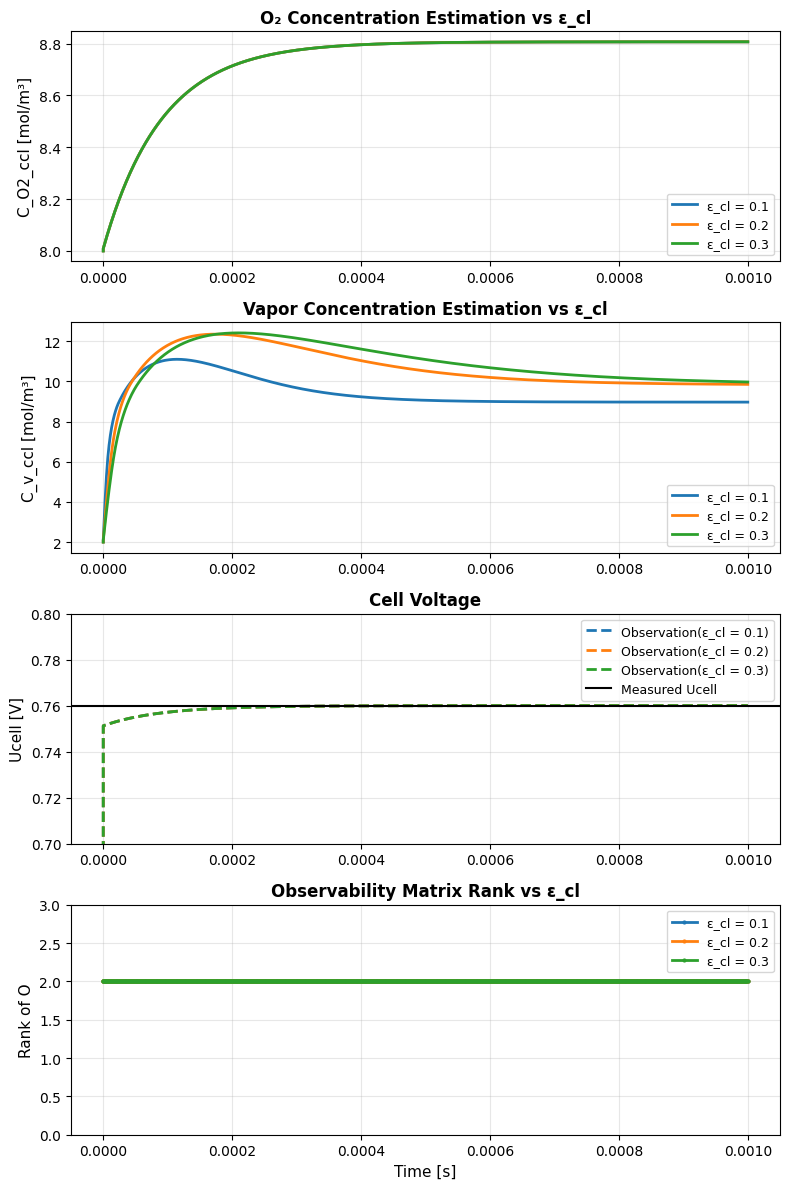

In [9]:

# Plotting — comparison across epsilon_cl values
colors = {0.1: 'tab:blue', 0.2: 'tab:orange', 0.3: 'tab:green'}

fig, axes = plt.subplots(4, 1, figsize=(8, 12))

for eps, res in results.items():
    lbl = f'ε_cl = {eps}'
    c = colors[eps]
    axes[0].plot(res['time'], res['C_O2'], color=c, linewidth=2, label=lbl)
    axes[1].plot(res['time'], res['C_v'], color=c, linewidth=2, label=lbl)
    axes[2].plot(res['time'], res['y_predicted'], color=c, linewidth=2, linestyle='--', label=f'Observation({lbl})')
    axes[3].plot(res['time'], res['obs_rank'], color=c, linewidth=2, marker='o', markersize=2, label=lbl)

# Measured output (same for all runs)
axes[2].axhline(y=0.76, color='k', linewidth=1.5, linestyle='-', label='Measured Ucell')

axes[0].set_ylabel('C_O2_ccl [mol/m³]', fontsize=11)
axes[0].set_title('O₂ Concentration Estimation vs ε_cl', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel('C_v_ccl [mol/m³]', fontsize=11)
axes[1].set_title('Vapor Concentration Estimation vs ε_cl', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].set_ylabel('Ucell [V]', fontsize=11)
axes[2].set_title('Cell Voltage', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0.7, 0.8])

axes[3].set_ylabel('Rank of O', fontsize=11)
axes[3].set_xlabel('Time [s]', fontsize=11)
axes[3].set_title('Observability Matrix Rank vs ε_cl', fontsize=12, fontweight='bold')
axes[3].set_ylim([0, 3])
axes[3].legend(fontsize=9)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
